# E-Commerce Shipping — Exploratory Data Analysis

**Data Analytics Portfolio Project | Python EDA**

---

This notebook analyses an **e-commerce shipping** dataset of 10,999 orders from
an international electronics retailer. The central question is **what makes a
delivery arrive late**. It is the Python EDA companion to the original **SQL**
project — same data, explored and visualised with pandas, matplotlib and
seaborn.

We follow the standard data-analysis workflow:

1. Business understanding
2. Data loading
3. Data inspection
4. Data cleaning & preparation
5. Exploratory Data Analysis (delivery performance, logistics, products,
   delay drivers, customers)
6. Key insights
7. Conclusion & recommendations

## 1. Business Understanding

The company ships products worldwide and wants to **reduce late deliveries**.
Each row is one order, with logistics details (warehouse, shipment mode,
weight), commercial details (cost, discount, product importance) and customer
details (rating, care calls, prior purchases).

The target column **`Reached.on.Time_Y.N`** is coded as:

- **`1` → the order did NOT reach on time (late)**
- **`0` → the order reached on time**

Key questions:

- **Overview:** What share of deliveries are late?
- **Logistics:** Do warehouse block and shipment mode affect lateness?
- **Products & discounts:** How do cost, weight, importance and discounts relate
  to late delivery?
- **Customers:** How do ratings, care calls and prior purchases relate to
  delivery outcomes?

## 2. Setup & Data Loading

We use the classic Python data-analysis stack: **pandas**/**numpy** for data
handling and **matplotlib**/**seaborn** for visualisation.

In [1]:
# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display & plot styling ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.edgecolor"] = "#cccccc"

PALETTE = "viridis"
ACCENT = "#2b6cb0"
LATE_COLORS = ["#38a169", "#e53e3e"]  # On Time (green), Late (red)
sns.set_palette("deep")

print("Libraries loaded.")
print("pandas", pd.__version__, "| numpy", np.__version__)

Libraries loaded.
pandas 3.0.3 | numpy 2.5.1


In [2]:
# --- Load the dataset ---
from pathlib import Path

DATA_DIR = Path("data")
df = pd.read_csv(DATA_DIR / "Ecommerce_Shipping_Data.csv")

print("Dataset shape:", df.shape)
print(f"{df.shape[0]:,} orders  x  {df.shape[1]} columns")
df.head()

Dataset shape: (10999, 12)
10,999 orders  x  12 columns


,ID,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


## 3. Data Inspection

A quick look at the columns, data types, summary statistics and missing values.

In [3]:
# Column names and data types.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10999 entries, 0 to 10998
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   10999 non-null  int64
 1   Warehouse_block      10999 non-null  str  
 2   Mode_of_Shipment     10999 non-null  str  
 3   Customer_care_calls  10999 non-null  int64
 4   Customer_rating      10999 non-null  int64
 5   Cost_of_the_Product  10999 non-null  int64
 6   Prior_purchases      10999 non-null  int64
 7   Product_importance   10999 non-null  str  
 8   Gender               10999 non-null  str  
 9   Discount_offered     10999 non-null  int64
 10  Weight_in_gms        10999 non-null  int64
 11  Reached.on.Time_Y.N  10999 non-null  int64
dtypes: int64(8), str(4)
memory usage: 1.0 MB


In [4]:
# Summary statistics for the numeric columns.
df.describe()

,ID,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
count,"10,999.00","10,999.00","10,999.00","10,999.00","10,999.00","10,999.00","10,999.00","10,999.00"
mean,"5,500.00",4.05,2.99,210.20,3.57,13.37,"3,634.02",0.60
std,"3,175.28",1.14,1.41,48.06,1.52,16.21,"1,635.38",0.49
min,1.00,2.00,1.00,96.00,2.00,1.00,"1,001.00",0.00
25%,"2,750.50",3.00,2.00,169.00,3.00,4.00,"1,839.50",0.00
50%,"5,500.00",4.00,3.00,214.00,3.00,7.00,"4,149.00",1.00
75%,"8,249.50",5.00,4.00,251.00,4.00,10.00,"5,050.00",1.00
max,"10,999.00",7.00,5.00,310.00,10.00,65.00,"7,846.00",1.00


In [5]:
# Missing values and duplicates.
print("Total missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Duplicate IDs:", int(df["ID"].duplicated().sum()))

Total missing values: 0
Duplicate rows: 0
Duplicate IDs: 0


## 4. Data Cleaning & Preparation

The data is already clean (no missing values, no duplicates). We mainly make it
**readable**:

- Rename the awkward `Reached.on.Time_Y.N` column.
- Create a human-readable **`Delivery_Status`** label (`On Time` / `Late`) and a
  numeric **`Late_Flag`** (1 = late) for rate calculations.
- Tidy the `Product_importance` capitalisation.
- Bucket weight and discount into bands for driver analysis.

In [6]:
# --- 4.1 Rename target and drop the ID column ---
df = df.rename(columns={"Reached.on.Time_Y.N": "Reached_On_Time"})

# --- 4.2 Readable delivery status ---
# In this dataset: 1 = NOT on time (Late), 0 = On Time.
df["Late_Flag"] = df["Reached_On_Time"]                 # 1 = late
df["Delivery_Status"] = df["Late_Flag"].map({0: "On Time", 1: "Late"})

# --- 4.3 Tidy categories ---
df["Product_importance"] = df["Product_importance"].str.capitalize()

# --- 4.4 Weight and discount bands ---
df["Weight_kg"] = df["Weight_in_gms"] / 1000
df["Weight_Band"] = pd.cut(
    df["Weight_in_gms"],
    bins=[0, 2000, 4000, 6000, 8000],
    labels=["<2kg", "2-4kg", "4-6kg", "6-8kg"])
df["Discount_Band"] = pd.cut(
    df["Discount_offered"],
    bins=[0, 5, 10, 20, 70],
    labels=["1-5%", "6-10%", "11-20%", "20%+"])

print("Preparation complete.")
print(df["Delivery_Status"].value_counts())
df[["Warehouse_block", "Mode_of_Shipment", "Cost_of_the_Product",
    "Discount_offered", "Weight_in_gms", "Delivery_Status"]].head()

Preparation complete.
Delivery_Status
Late       6563
On Time    4436
Name: count, dtype: int64


,Warehouse_block,Mode_of_Shipment,Cost_of_the_Product,Discount_offered,Weight_in_gms,Delivery_Status
0,D,Flight,177,44,1233,Late
1,F,Flight,216,59,3088,Late
2,A,Flight,183,48,3374,Late
3,B,Flight,176,10,1177,Late
4,C,Flight,184,46,2484,Late


## 5. Exploratory Data Analysis

### 5.1 Delivery Performance Overview

In [7]:
# Headline KPIs.
total_orders = len(df)
late_orders  = int(df["Late_Flag"].sum())
late_rate    = df["Late_Flag"].mean() * 100
avg_cost     = df["Cost_of_the_Product"].mean()
avg_disc     = df["Discount_offered"].mean()
avg_weight   = df["Weight_kg"].mean()

print(f"Total Orders     : {total_orders:,}")
print(f"Late Deliveries  : {late_orders:,}")
print(f"Late Rate        : {late_rate:.1f}%")
print(f"On-Time Rate     : {100 - late_rate:.1f}%")
print(f"Avg Product Cost : ${avg_cost:.0f}")
print(f"Avg Discount     : {avg_disc:.1f}%")
print(f"Avg Weight       : {avg_weight:.2f} kg")

Total Orders     : 10,999
Late Deliveries  : 6,563
Late Rate        : 59.7%
On-Time Rate     : 40.3%
Avg Product Cost : $210
Avg Discount     : 13.4%
Avg Weight       : 3.63 kg


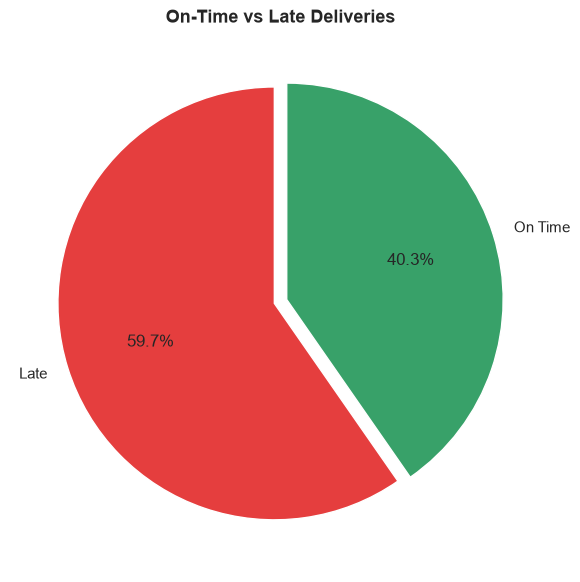

In [8]:
# On-time vs late split.
status = df["Delivery_Status"].value_counts()
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(status.values, labels=status.index, autopct="%1.1f%%", startangle=90,
       colors=["#e53e3e" if s == "Late" else "#38a169" for s in status.index],
       explode=[0.03] * len(status))
ax.set_title("On-Time vs Late Deliveries")
plt.tight_layout(); plt.show()

### 5.2 Logistics: Warehouse & Shipment Mode

We look at both the **volume** of orders and the **late rate** for each
warehouse block and shipment mode. (A helper function draws the late-rate bars.)

In [9]:
def late_rate_by(col, ax, palette=PALETTE, order=None):
    # Plot late % by a categorical column onto the given axis.
    rate = df.groupby(col)["Late_Flag"].mean().mul(100)
    if order is not None:
        rate = rate.reindex(order)
    rate = rate.sort_values(ascending=False) if order is None else rate
    sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)
    ax.axhline(df["Late_Flag"].mean() * 100, color="black",
               linestyle="--", linewidth=1, label="Overall avg")
    ax.set_ylabel("Late %"); ax.set_xlabel("")
    ax.legend()
    return rate

print("Helper ready.")

Helper ready.


C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2334130331.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=blocks.index, y=blocks.values, palette=PALETTE, ax=axes[0])
C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2723137397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)


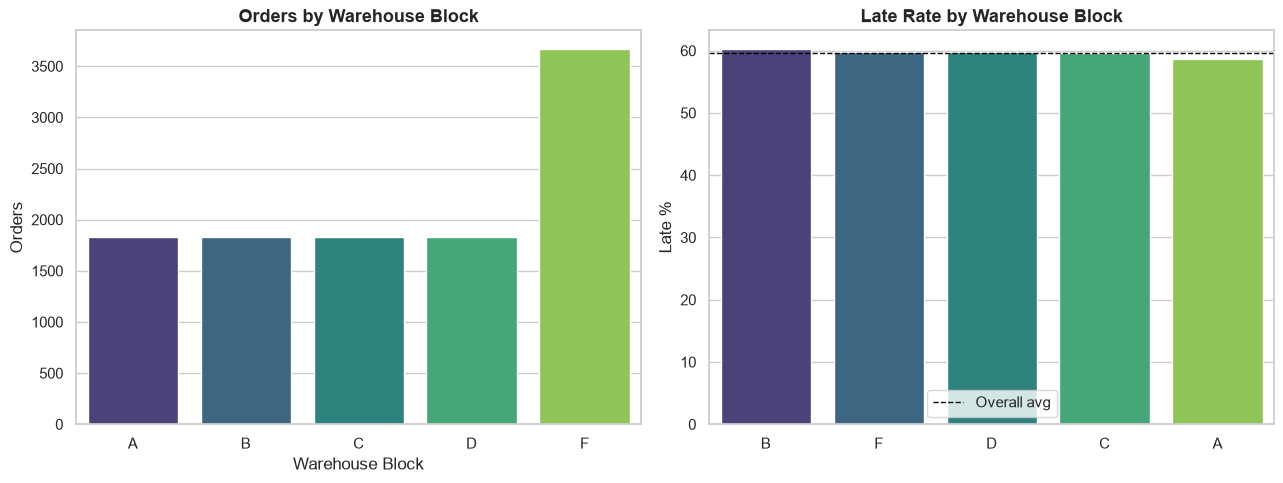

In [10]:
# Warehouse block: volume and late rate.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

blocks = df["Warehouse_block"].value_counts().sort_index()
sns.barplot(x=blocks.index, y=blocks.values, palette=PALETTE, ax=axes[0])
axes[0].set_title("Orders by Warehouse Block")
axes[0].set_xlabel("Warehouse Block"); axes[0].set_ylabel("Orders")

late_rate_by("Warehouse_block", axes[1])
axes[1].set_title("Late Rate by Warehouse Block")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\3857500637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modes.index, y=modes.values, palette="mako", ax=axes[0])
C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2723137397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)


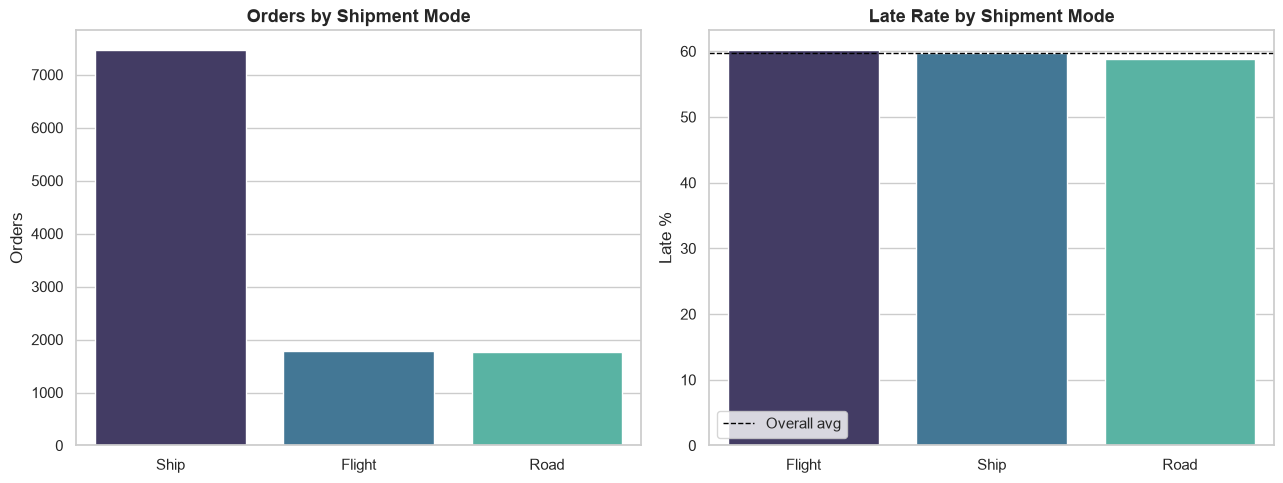

In [11]:
# Shipment mode: volume and late rate.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modes = df["Mode_of_Shipment"].value_counts()
sns.barplot(x=modes.index, y=modes.values, palette="mako", ax=axes[0])
axes[0].set_title("Orders by Shipment Mode")
axes[0].set_xlabel(""); axes[0].set_ylabel("Orders")

late_rate_by("Mode_of_Shipment", axes[1], palette="mako")
axes[1].set_title("Late Rate by Shipment Mode")

plt.tight_layout(); plt.show()

### 5.3 Products, Weight & Discounts

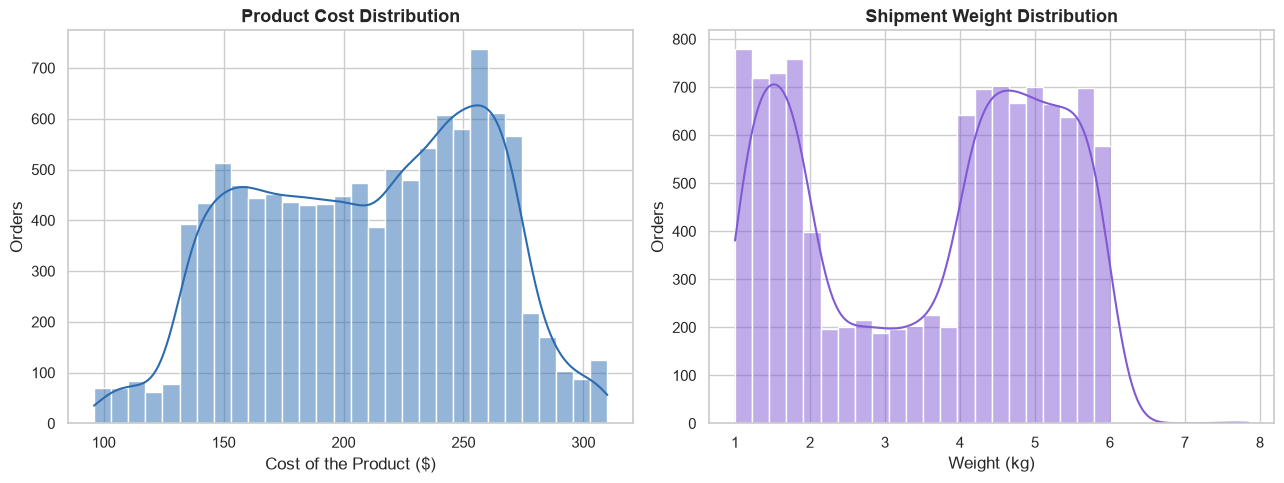

In [12]:
# Distributions of product cost and weight.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df["Cost_of_the_Product"], bins=30, kde=True, color=ACCENT, ax=axes[0])
axes[0].set_title("Product Cost Distribution")
axes[0].set_xlabel("Cost of the Product ($)"); axes[0].set_ylabel("Orders")

sns.histplot(df["Weight_kg"], bins=30, kde=True, color="#805ad5", ax=axes[1])
axes[1].set_title("Shipment Weight Distribution")
axes[1].set_xlabel("Weight (kg)"); axes[1].set_ylabel("Orders")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\70523557.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.index, y=imp.values, palette="crest", ax=axes[0])
C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2723137397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)


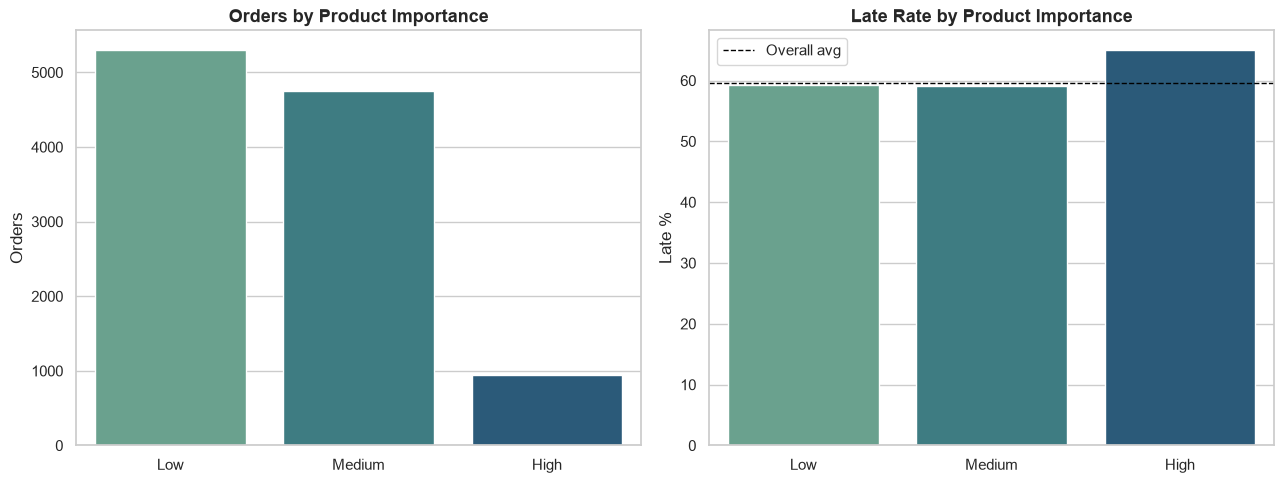

In [13]:
# Product importance: volume and late rate.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

imp_order = ["Low", "Medium", "High"]
imp = df["Product_importance"].value_counts().reindex(imp_order)
sns.barplot(x=imp.index, y=imp.values, palette="crest", ax=axes[0])
axes[0].set_title("Orders by Product Importance")
axes[0].set_xlabel(""); axes[0].set_ylabel("Orders")

late_rate_by("Product_importance", axes[1], palette="crest", order=imp_order)
axes[1].set_title("Late Rate by Product Importance")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\926528515.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Delivery_Status", y="Discount_offered",
C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2723137397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)


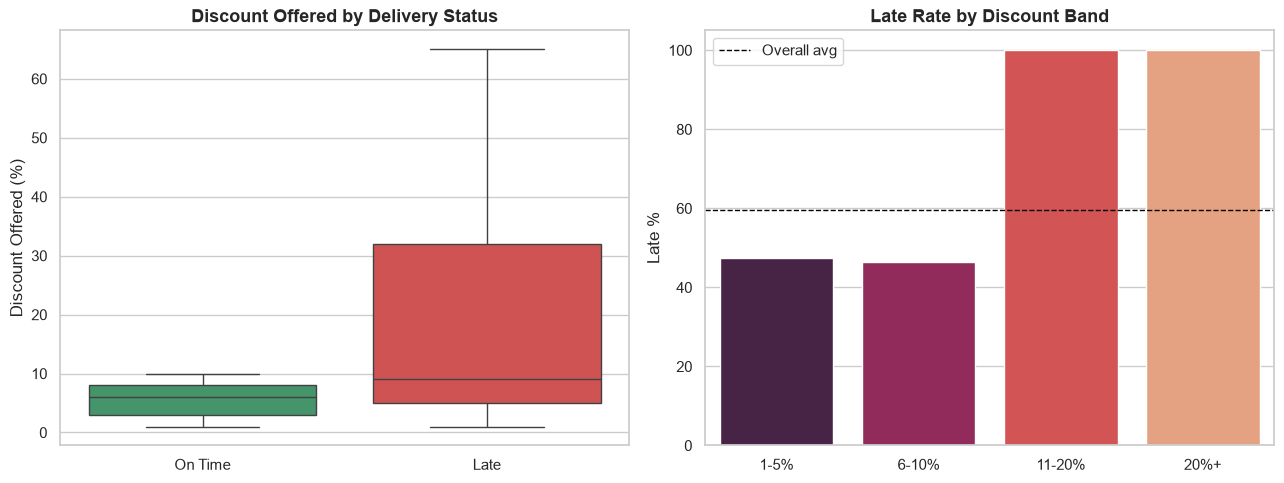

In [14]:
# Discount is a strong signal: compare discounts for on-time vs late orders.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Delivery_Status", y="Discount_offered",
            palette=["#38a169", "#e53e3e"],
            order=["On Time", "Late"], ax=axes[0])
axes[0].set_title("Discount Offered by Delivery Status")
axes[0].set_xlabel(""); axes[0].set_ylabel("Discount Offered (%)")

late_rate_by("Discount_Band", axes[1], palette="rocket",
             order=["1-5%", "6-10%", "11-20%", "20%+"])
axes[1].set_title("Late Rate by Discount Band")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\3727568576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Delivery_Status", y="Weight_kg",
C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2723137397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)


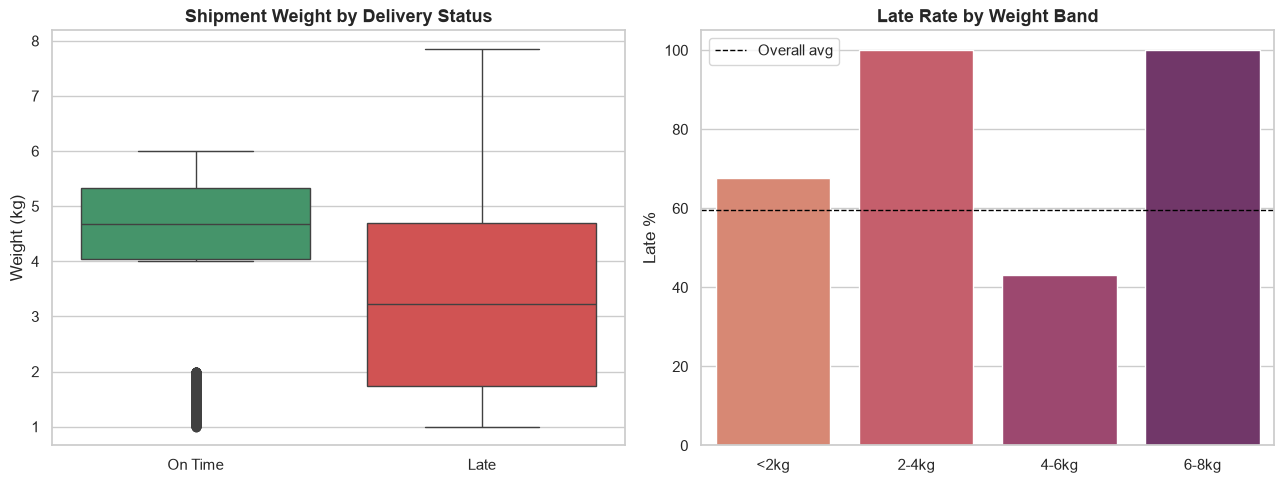

In [15]:
# Weight is the other strong signal.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Delivery_Status", y="Weight_kg",
            palette=["#38a169", "#e53e3e"],
            order=["On Time", "Late"], ax=axes[0])
axes[0].set_title("Shipment Weight by Delivery Status")
axes[0].set_xlabel(""); axes[0].set_ylabel("Weight (kg)")

late_rate_by("Weight_Band", axes[1], palette="flare",
             order=["<2kg", "2-4kg", "4-6kg", "6-8kg"])
axes[1].set_title("Late Rate by Weight Band")

plt.tight_layout(); plt.show()

### 5.4 Customer Signals

C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2723137397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)
C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2723137397.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rate.index.astype(str), y=rate.values, palette=palette, ax=ax)


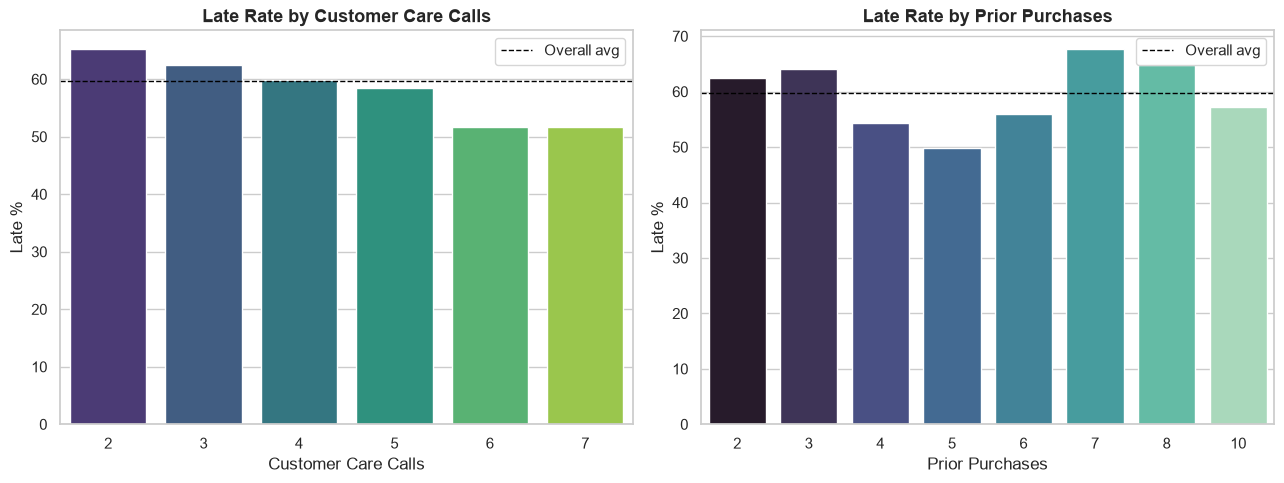

In [16]:
# Customer care calls and prior purchases vs late rate.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

late_rate_by("Customer_care_calls", axes[0], palette=PALETTE,
             order=sorted(df["Customer_care_calls"].unique()))
axes[0].set_title("Late Rate by Customer Care Calls")
axes[0].set_xlabel("Customer Care Calls")

late_rate_by("Prior_purchases", axes[1], palette="mako",
             order=sorted(df["Prior_purchases"].unique()))
axes[1].set_title("Late Rate by Prior Purchases")
axes[1].set_xlabel("Prior Purchases")

plt.tight_layout(); plt.show()

C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2357050962.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating.index, y=rating.values, palette="crest", ax=axes[0])
C:\Users\arun_\AppData\Local\Temp\ipykernel_35212\2357050962.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_late.index, y=gender_late.values, palette="Set2", ax=axes[1])


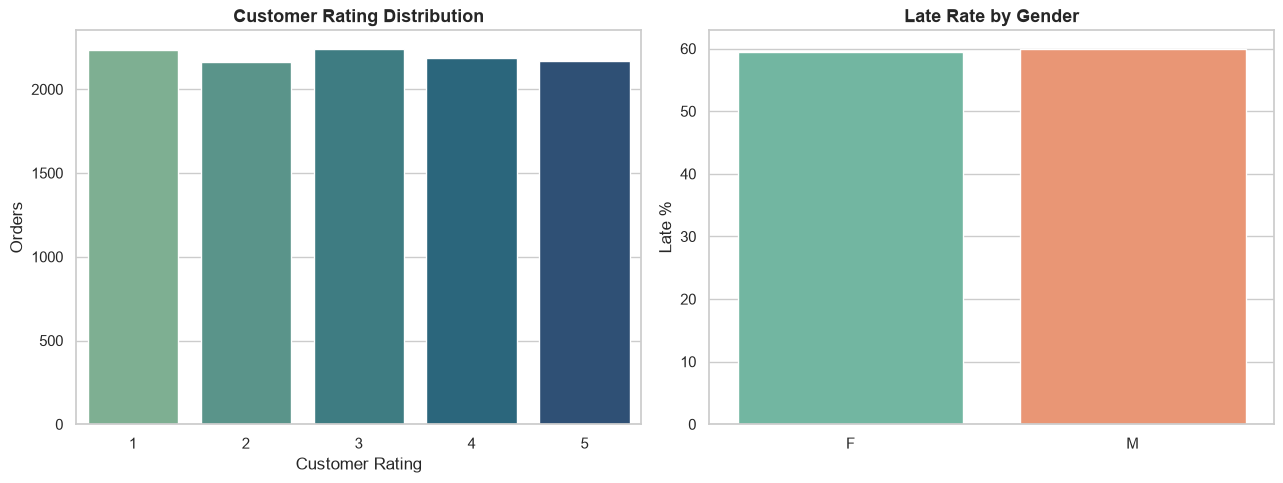

In [17]:
# Customer rating and gender.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rating = df["Customer_rating"].value_counts().sort_index()
sns.barplot(x=rating.index, y=rating.values, palette="crest", ax=axes[0])
axes[0].set_title("Customer Rating Distribution")
axes[0].set_xlabel("Customer Rating"); axes[0].set_ylabel("Orders")

gender_late = df.groupby("Gender")["Late_Flag"].mean().mul(100)
sns.barplot(x=gender_late.index, y=gender_late.values, palette="Set2", ax=axes[1])
axes[1].set_title("Late Rate by Gender")
axes[1].set_xlabel(""); axes[1].set_ylabel("Late %")

plt.tight_layout(); plt.show()

### 5.5 Correlation Between Numeric Features

Which numeric features move together with late delivery (`Late_Flag`)?

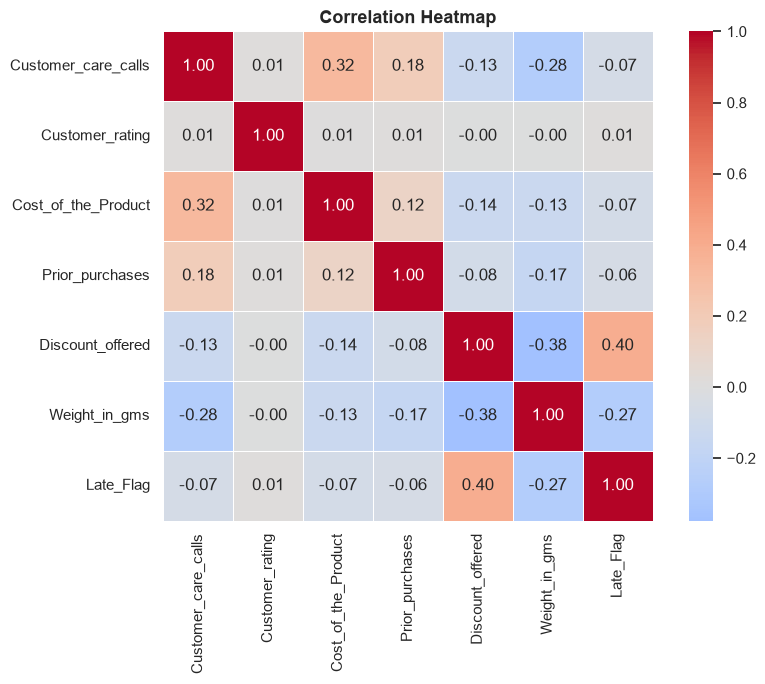

Correlation with Late_Flag (sorted):
Weight_in_gms         -0.27
Cost_of_the_Product   -0.07
Customer_care_calls   -0.07
Prior_purchases       -0.06
Customer_rating        0.01
Discount_offered       0.40
Name: Late_Flag, dtype: float64


In [18]:
num_cols = ["Customer_care_calls", "Customer_rating", "Cost_of_the_Product",
            "Prior_purchases", "Discount_offered", "Weight_in_gms", "Late_Flag"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f",
            square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout(); plt.show()

print("Correlation with Late_Flag (sorted):")
print(corr["Late_Flag"].drop("Late_Flag").sort_values())

## 6. Key Insights

> The numbers below are computed from the data so they always stay accurate.

In [19]:
block_rate = df.groupby("Warehouse_block")["Late_Flag"].mean().mul(100)
mode_rate = df.groupby("Mode_of_Shipment")["Late_Flag"].mean().mul(100)
disc_late = df.loc[df["Late_Flag"] == 1, "Discount_offered"].mean()
disc_ontime = df.loc[df["Late_Flag"] == 0, "Discount_offered"].mean()
wt_late = df.loc[df["Late_Flag"] == 1, "Weight_kg"].mean()
wt_ontime = df.loc[df["Late_Flag"] == 0, "Weight_kg"].mean()
disc_corr = df["Discount_offered"].corr(df["Late_Flag"])
wt_corr = df["Weight_in_gms"].corr(df["Late_Flag"])

print("KEY INSIGHTS")
print("=" * 60)
print(f"1. {late_rate:.1f}% of all orders ({late_orders:,}) arrived late.")
print(f"2. Ship is the most-used mode ({modes.iloc[0]:,} of {total_orders:,} orders).")
print(f"3. Late rate is similar across warehouse blocks "
      f"({block_rate.min():.1f}%-{block_rate.max():.1f}%).")
print(f"4. Late orders had a HIGHER avg discount "
      f"({disc_late:.1f}% vs {disc_ontime:.1f}% for on-time).")
print(f"5. Late orders were LIGHTER on average "
      f"({wt_late:.2f}kg vs {wt_ontime:.2f}kg for on-time).")
print(f"6. Discount vs lateness correlation: {disc_corr:+.2f} (strongest driver).")
print(f"7. Weight vs lateness correlation: {wt_corr:+.2f}.")
print(f"8. Avg product cost ${avg_cost:.0f}; avg discount {avg_disc:.1f}%.")

KEY INSIGHTS
1. 59.7% of all orders (6,563) arrived late.
2. Ship is the most-used mode (7,462 of 10,999 orders).
3. Late rate is similar across warehouse blocks (58.6%-60.2%).
4. Late orders had a HIGHER avg discount (18.7% vs 5.5% for on-time).
5. Late orders were LIGHTER on average (3.27kg vs 4.17kg for on-time).
6. Discount vs lateness correlation: +0.40 (strongest driver).
7. Weight vs lateness correlation: -0.27.
8. Avg product cost $210; avg discount 13.4%.


## 7. Conclusion & Recommendations

**Conclusion.** Roughly **6 in 10 orders arrive late**, so late delivery is the
norm rather than the exception. The strongest signals are **discount offered**
(heavily discounted orders are far more likely to be late) and **shipment
weight** (lighter parcels tend to run late). Warehouse block and gender show
little effect.

**Recommendations.**

1. **Investigate the discount–delay link.** Heavily discounted orders may be
   deprioritised in fulfilment; review how promotional orders are queued and
   picked.
2. **Fix handling of light parcels.** Lighter shipments run late more often —
   check whether they wait to be consolidated before dispatch.
3. **Set realistic delivery promises** given the ~60% baseline late rate, and
   focus operational improvements on the highest-late-rate segments identified
   above.
4. **Reduce customer-care load.** More care calls are associated with lateness;
   proactive status updates could cut both calls and dissatisfaction.

## 8. Future Work

- Build a **classification model** (logistic regression / random forest) to
  predict late delivery and rank feature importance.
- Add **cost-of-delay analysis** to quantify the revenue impact of late orders.
- Combine shipment mode × importance × weight into a **risk score** for routing
  decisions.

---
*Python EDA companion to the original SQL e-commerce shipping project.*